First 5 Rows
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

Dataset Shape
(303, 14)

Column Names
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    ----

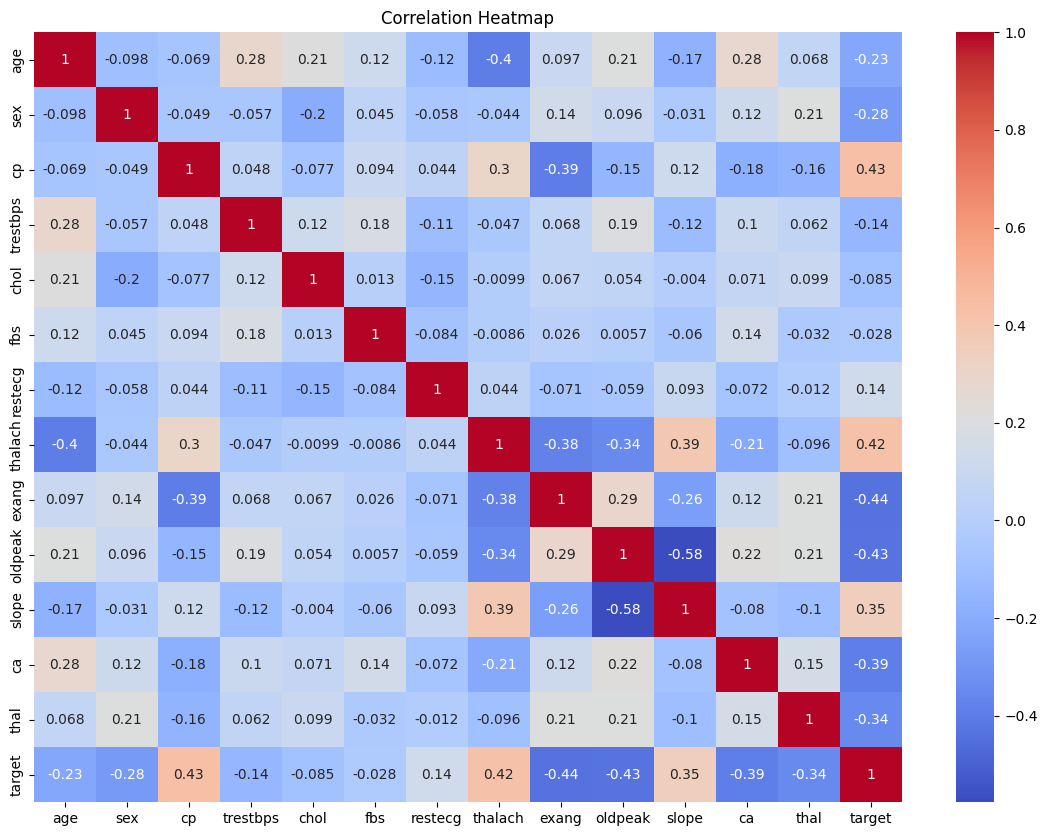

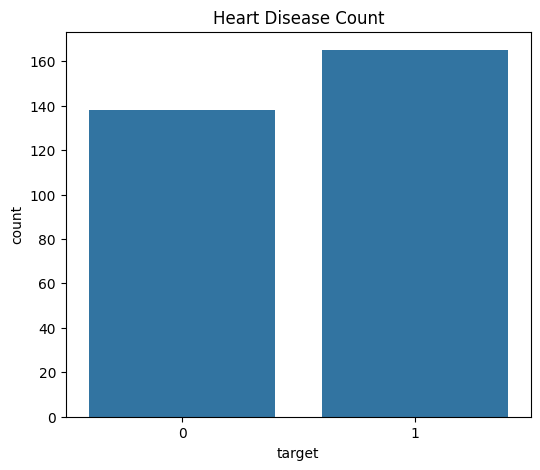

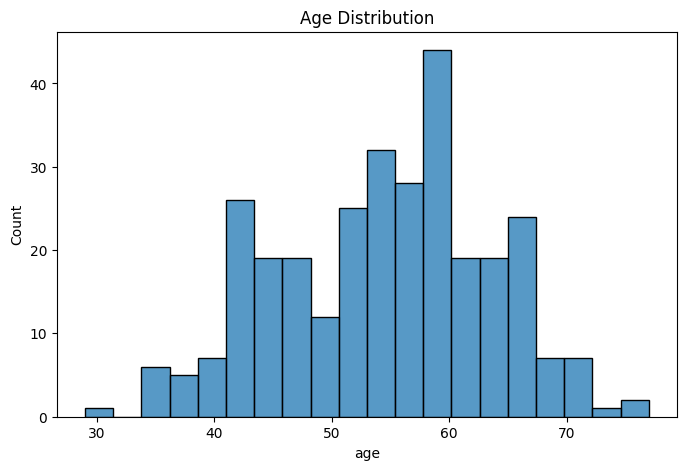


Logistic Regression Accuracy
0.8524590163934426

KNN Accuracy
0.9016393442622951

Decision Tree Accuracy
0.7540983606557377

Random Forest Accuracy
0.8360655737704918

MODEL COMPARISON
                 Model  Accuracy
0  Logistic Regression  0.852459
1                  KNN  0.901639
2        Decision Tree  0.754098
3        Random Forest  0.836066


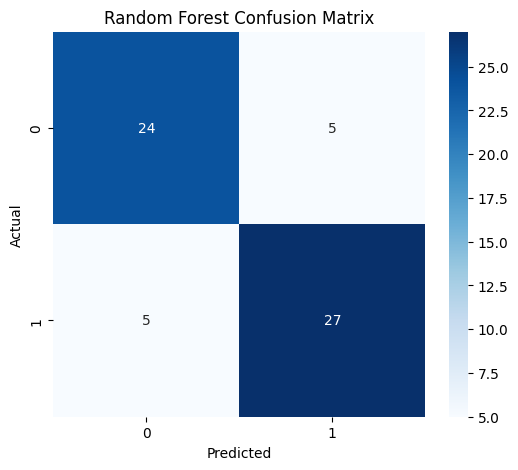


CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.84      0.84      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61


FEATURE IMPORTANCE
     Feature  Importance
9    oldpeak    0.128485
7    thalach    0.119725
11        ca    0.115533
2         cp    0.103792
12      thal    0.093300
0        age    0.092811
3   trestbps    0.077537
8      exang    0.075809
4       chol    0.074812
10     slope    0.051058
1        sex    0.035658
6    restecg    0.019782
5        fbs    0.011698


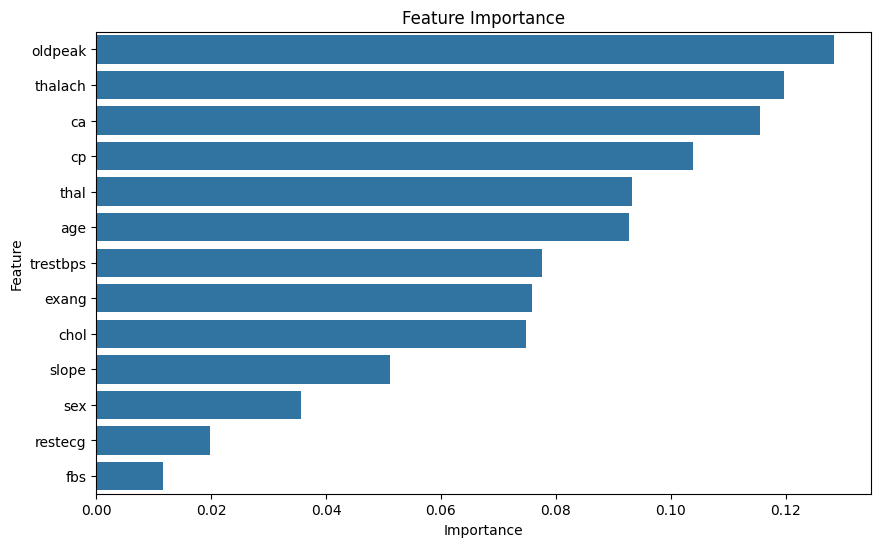


CUSTOM PREDICTION
Person DOES NOT have Heart Disease


C:\Users\Siddharth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [4]:
# =========================================================
# HEART DISEASE PREDICTION PROJECT
# FULL WORKING CODE FOR JUPYTERLAB
# =========================================================

# =========================
# STEP 1 : IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# =========================
# STEP 2 : LOAD DATASET
# =========================

# IMPORTANT:
# Put heart.csv file in same folder as Jupyter Notebook

df = pd.read_csv("heart_v1.csv")

# =========================
# STEP 3 : SHOW DATA
# =========================

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# =========================
# STEP 4 : DATA VISUALIZATION
# =========================

# Correlation Heatmap

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# =========================

# Target Count Plot

plt.figure(figsize=(6,5))

sns.countplot(
    x="target",
    data=df
)

plt.title("Heart Disease Count")
plt.show()

# =========================

# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=20
)

plt.title("Age Distribution")
plt.show()

# =========================
# STEP 5 : DEFINE X AND y
# =========================

X = df.drop("target", axis=1)

y = df["target"]

# =========================
# STEP 6 : TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# STEP 7 : FEATURE SCALING
# =========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# =========================
# STEP 8 : LOGISTIC REGRESSION
# =========================

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("\n===================================")
print("Logistic Regression Accuracy")
print("===================================")

print(lr_accuracy)

# =========================
# STEP 9 : KNN MODEL
# =========================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("\n===================================")
print("KNN Accuracy")
print("===================================")

print(knn_accuracy)

# =========================
# STEP 10 : DECISION TREE
# =========================

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("\n===================================")
print("Decision Tree Accuracy")
print("===================================")

print(dt_accuracy)

# =========================
# STEP 11 : RANDOM FOREST
# =========================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\n===================================")
print("Random Forest Accuracy")
print("===================================")

print(rf_accuracy)

# =========================
# STEP 12 : MODEL COMPARISON
# =========================

models = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],
    
    "Accuracy": [
        lr_accuracy,
        knn_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

print("\n===================================")
print("MODEL COMPARISON")
print("===================================")

print(models)

# =========================
# STEP 13 : CONFUSION MATRIX
# =========================

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

# =========================
# STEP 14 : CLASSIFICATION REPORT
# =========================

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

# =========================
# STEP 15 : FEATURE IMPORTANCE
# =========================

importance = rf.feature_importances_

feature_names = X.columns

feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

print("\n===================================")
print("FEATURE IMPORTANCE")
print("===================================")

print(feature_df)

# =========================
# STEP 16 : FEATURE IMPORTANCE GRAPH
# =========================

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df
)

plt.title("Feature Importance")

plt.show()

# =========================
# STEP 17 : CUSTOM PREDICTION
# =========================

# Example Input Data
# age,sex,cp,trestbps,chol,fbs,
# restecg,thalach,exang,oldpeak,
# slope,ca,thal

sample_data = [[
    52,
    1,
    0,
    125,
    212,
    0,
    1,
    168,
    0,
    1.0,
    2,
    2,
    3
]]

# Scaling

sample_data = scaler.transform(sample_data)

# Prediction

prediction = rf.predict(sample_data)

print("\n===================================")
print("CUSTOM PREDICTION")
print("===================================")

if prediction[0] == 1:
    print("Person HAS Heart Disease")
else:
    print("Person DOES NOT have Heart Disease")

# =========================================================
# END OF PROJECT
# =========================================================